In [707]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
from IPython.display import display
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [539]:
DATA_DIR = os.path.expanduser("data/fingernail-anemia")
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")

In [910]:
def load_metadata(csv_path):
    df = pd.read_csv(csv_path)
    df["HB_LEVEL_GperDeciL"] = df["HB_LEVEL_GperL"] / 10

    def remark_class(hb):
        return "Anemic" if hb < 120 else "Non-anemic"

    def severity_class(hb):
        if hb < 80:
            return "Severe"
        elif hb < 100:
            return "Moderate"
        elif hb < 120:
            return "Mild"
        else:
            return "Non-anemic"

    df["Remark"] = df["HB_LEVEL_GperL"].apply(remark_class)
    df["Severity"] = df["HB_LEVEL_GperL"].apply(severity_class)
    df['NAIL_BOUNDING_BOXES'] = df['NAIL_BOUNDING_BOXES'].apply(ast.literal_eval)
    df['SKIN_BOUNDING_BOXES'] = df['SKIN_BOUNDING_BOXES'].apply(ast.literal_eval)
    return df

def crop_regions(image, bboxes):
    crops = []
    for bbox in bboxes:
        y1, x1, y2, x2 = bbox
        crop = image[y1:y2, x1:x2]
        if crop.size > 0:
            crops.append(crop)
    return crops

def load_and_crop_regions(image_dir, row, region_type):
    pid = str(row['PATIENT_ID'])
    label = 'Anemic' if row['HB_LEVEL_GperDeciL'] < 12.0 else 'Non-anemic'
    img_path = os.path.join(image_dir, label, f"{pid}.jpg")

    if not os.path.exists(img_path):
        return None, []

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes = row[region_type]
    return image, crop_regions(image, bboxes)

def plot_hb_distribution(df):
    plt.figure(figsize=(4, 4))
    plt.hist(df['HB_LEVEL_GperDeciL'], bins=20, color='blue')
    plt.title('Distribution of Hemoglobin Values (g/dL)', fontsize=12)
    plt.xlabel('Hemoglobin Level (g/dL)', fontsize=10)
    plt.ylabel('Density', fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_rgb_channel_distributions(images, label='Cropped Regions'):
    if len(images) == 0:
        print("No images to plot.")
        return

    r_vals, g_vals, b_vals = [], [], []
    for img in images:
        b, g, r = cv2.split(img)
        r_vals.extend(r.flatten())
        g_vals.extend(g.flatten())
        b_vals.extend(b.flatten())

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].hist(r_vals, bins=20, color='red', density=True)
    axs[0].set_title(f'R Channel ({label})', {'fontsize': 12})

    axs[1].hist(g_vals, bins=20, color='green', density=True)
    axs[1].set_title(f'G Channel ({label})', {'fontsize': 12})

    axs[2].hist(b_vals, bins=20, color='blue', density=True)
    axs[2].set_title(f'B Channel ({label})', {'fontsize': 12})

    for ax in axs:
        ax.set_xlim([0, 255])
        ax.set_xlabel('Pixel Intensity', {'fontsize': 10})
        ax.set_ylabel('Density', {'fontsize': 10})

    plt.tight_layout()
    plt.show()

def plot_white_reference_distributions(images):
    r_means, g_means, b_means = [], [], []
    for img in images:
        b, g, r = cv2.split(img)
        r_means.append(np.mean(r))
        g_means.append(np.mean(g))
        b_means.append(np.mean(b))

    color_temp = [((r + g + b) / 3) for r, g, b in zip(r_means, g_means, b_means)]

    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    axs = axs.ravel()

    channels = [r_means, g_means, b_means]
    colors = ['red', 'green', 'blue']
    titles = ['R', 'G', 'B']

    for i, (channel, color, title) in enumerate(zip(channels, colors, titles)):
        axs[i].hist(channel, bins=20, color=color)
        axs[i].set_title(f"{title} mean intensity = {int(np.mean(channel))} ± {int(np.std(channel))}")
        axs[i].set_xlabel(f"Intensity in {title} channel")
        axs[i].set_ylabel("Number of images in dataset")

    axs[3].hist(color_temp, bins=20, color='purple')
    axs[3].set_title(f"Color temperature = {int(np.mean(color_temp))} ± {int(np.std(color_temp))} K")
    axs[3].set_xlabel("Color temperature of white reference, K")
    axs[3].set_ylabel("Number of images in dataset")

    plt.tight_layout()
    plt.show()

def plot_class_kde_balanced(metadata, balanced_remark, balanced_severity):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    for ax, balanced_df, label in zip(
        axs,
        [balanced_remark, balanced_severity],
        ['Remark', 'Severity']
    ):
        hb_vals = metadata['HB_LEVEL_GperDeciL'].values
        hb_balanced = balanced_df['HB_LEVEL_GperDeciL'].values

        ax.hist(hb_vals, bins=20, density=True, alpha=0.4, color='blue', label='Before')
        ax.hist(hb_balanced, bins=20, density=True, alpha=0.4, color='red', label='After')
        ax.set_title(f"KDE by {label} (Before vs After Balancing)")
        ax.set_xlabel("Hb level (g/L)")
        ax.set_ylabel("Density")
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_class_distribution_by_class(df_remark, df_severity):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    axs[0].set_title("KDE Balanced by Remark")
    for label in df_remark['Remark'].unique():
        subset = df_remark[df_remark['Remark'] == label]
        axs[0].hist(subset['HB_LEVEL_GperDeciL'], bins=10, alpha=0.6, label=label)
    axs[0].set_xlabel("Hb level (g/dL)")
    axs[0].set_ylabel("Density")
    axs[0].legend()

    axs[1].set_title("KDE Balanced by Severity")
    for label in df_severity['Severity'].unique():
        subset = df_severity[df_severity['Severity'] == label]
        axs[1].hist(subset['HB_LEVEL_GperDeciL'], bins=10, alpha=0.6, label=label)
    axs[1].set_xlabel("Hb level (g/dL)")
    axs[1].set_ylabel("Density")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

def plot_target_balancing(metadata, balanced_df):
    hb_vals = metadata['HB_LEVEL_GperDeciL'].values
    hb_balanced = balanced_df['HB_LEVEL_GperDeciL'].values
    kde = gaussian_kde(hb_vals)
    x_vals = np.linspace(min(hb_vals), max(hb_vals), 200)
    y_vals = kde(x_vals)
    probs = 1.0 / (kde(hb_vals) + 1e-6)
    probs /= probs.sum()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    axs[0].hist(hb_vals, bins=20, density=True, alpha=0.6, color='blue', label='Empirical')
    axs[0].plot(x_vals, y_vals, 'r--', label='KDE')
    axs[0].set_title('Target KDE vs Empirical')
    axs[0].set_xlabel('Hb level (g/dL)')
    axs[0].set_ylabel('Probability density')
    axs[0].legend()

    axs[1].scatter(hb_vals, probs, color='blue', alpha=0.6)
    axs[1].set_title('Sampling Weights')
    axs[1].set_xlabel('Hb level (g/dL)')
    axs[1].set_ylabel('Probability')

    axs[2].hist(hb_vals, bins=20, color='blue', label='Before', alpha=0.4, density=True)
    axs[2].hist(hb_balanced, bins=20, color='red', label='After', alpha=0.4, density=True)
    axs[2].set_title('Distribution After Balancing')
    axs[2].set_xlabel('Hb level (g/dL)')
    axs[2].set_ylabel('Density')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

def kde_balance_by_severity(df, target_column="HB_LEVEL_GperDeciL", severity_column="Severity",
                            n_per_class=20, bandwidth=0.5, seed=42):
    np.random.seed(seed)
    balanced_dfs = []
    for severity in df[severity_column].unique():
        group = df[df[severity_column] == severity]
        hb_vals = group[target_column].values
        if len(group) <= n_per_class:
            balanced_dfs.append(group)
        else:
            kde = gaussian_kde(hb_vals, bw_method=bandwidth / np.std(hb_vals))
            density = kde(hb_vals)
            probs = 1.0 / (density + 1e-6)
            probs /= probs.sum()
            sampled = group.sample(n=n_per_class, weights=probs, replace=False, random_state=seed)
            balanced_dfs.append(sampled)
    return pd.concat(balanced_dfs).reset_index(drop=True)

def kde_balance_by_remark(df, target_column="HB_LEVEL_GperDeciL", remark_column="Remark",
                            n_per_class=50, bandwidth=0.5, seed=42):
    np.random.seed(seed)
    balanced_dfs = []
    for remark in df[remark_column].unique():
        group = df[df[remark_column] == remark]
        hb_vals = group[target_column].values
        if len(group) <= n_per_class:
            balanced_dfs.append(group)
        else:
            kde = gaussian_kde(hb_vals, bw_method=bandwidth / np.std(hb_vals))
            density = kde(hb_vals)
            probs = 1.0 / (density + 1e-6)
            probs /= probs.sum()
            sampled = group.sample(n=n_per_class, weights=probs, replace=False, random_state=seed)
            balanced_dfs.append(sampled)
    return pd.concat(balanced_dfs).reset_index(drop=True)

def plot_sample_images(df, data_dir, indices):
    fig = plt.figure(figsize=(20, 14))
    gs = GridSpec(2, 4, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

    # (a) 3 patient images (square)
    for i, idx in enumerate(indices):
        row = df.sample(3).iloc[idx]
        img, _ = load_and_crop_regions(data_dir, row, 'NAIL_BOUNDING_BOXES')
        ax = fig.add_subplot(gs[0, i])
        # Resize while preserving bbox proportions
        orig_h, orig_w = img.shape[:2]
        target_size = orig_h
        img_resized = cv2.resize(img, (target_size, target_size))
        scale_x = target_size / orig_w
        scale_y = target_size / orig_h

        ax.imshow(img_resized.astype(np.uint8))

        # Draw scaled bounding boxes
        for (y1, x1, y2, x2) in row['NAIL_BOUNDING_BOXES']:
            rect = patches.Rectangle((x1 * scale_x, y1 * scale_y),
                                    (x2 - x1) * scale_x, (y2 - y1) * scale_y,
                                    edgecolor='red', facecolor='none', linewidth=1)
            ax.add_patch(rect)
        for (y1, x1, y2, x2) in row['SKIN_BOUNDING_BOXES']:
            rect = patches.Rectangle((x1 * scale_x, y1 * scale_y),
                                    (x2 - x1) * scale_x, (y2 - y1) * scale_y,
                                    edgecolor='blue', facecolor='none', linewidth=1)
            ax.add_patch(rect)
            
        white_region_rectangle = patches.Rectangle(xy=(350*scale_x,300*scale_y),
                                    width=50*scale_x,height=50*scale_y,fill=None,
                                    color='green',linewidth=1)
        ax.add_patch(white_region_rectangle)

        # ax.add_patch(rect)
        ax.set_title(f"[Hb] = {int(row['HB_LEVEL_GperDeciL'])} g/dL")
        ax.axis('off')
    # plt.tight_layout()
    plt.show()

def plot_segmented_regions(df, data_dir, index):
    row = df.iloc[index]
    _, nail_crops = load_and_crop_regions(data_dir, row, 'NAIL_BOUNDING_BOXES')
    _, skin_crops = load_and_crop_regions(data_dir, row, 'SKIN_BOUNDING_BOXES')

    fig, axes = plt.subplots(2, 3, figsize=(8, 5))
    fig.suptitle(f"Segmented Nail and Skin Regions [Hb = {int(row['HB_LEVEL_GperDeciL'])} g/dL]", fontsize=12)

    for i in range(3):
        if i < len(nail_crops):
            axes[0, i].imshow(cv2.resize(nail_crops[i], (224, 224)))
            axes[0, i].axis('off')
            axes[0, i].set_title(f"Nail {i+1}")
        else:
            axes[0, i].axis('off')

        if i < len(skin_crops):
            axes[1, i].imshow(cv2.resize(skin_crops[i], (224, 224)))
            axes[1, i].axis('off')
            axes[1, i].set_title(f"Skin {i+1}")
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def calculate_percentile_features(images, percentiles=[5,15,25,50,75,85,95]):
    features = defaultdict(list)
    for img in images:
        for p in percentiles:
            rgb_vals = [np.percentile(img[:,:,c].ravel(), p) for c in range(3)]
            features[f"RGB_p{p}"].append(np.mean(rgb_vals))
    return pd.DataFrame(features)

def plot_percentile_histograms_by_class(df, data_dir):
    percentiles = [5, 15, 25, 50, 75, 85, 95]
    fig, axs = plt.subplots(2, 2, figsize=(9, 9))
    axs = axs.ravel()
    class_labels = ['Remark', 'Severity']
    regions = ['Nail', 'Skin']

    for ax_idx, (class_col, region_type) in enumerate([(c, r) for c in class_labels for r in regions]):
        all_features = []

        for _, row in df.iterrows():
            _, crops = load_and_crop_regions(data_dir, row, f'{region_type.upper()}_BOUNDING_BOXES')
            region_df = calculate_percentile_features(crops).mean().to_frame().T
            region_df['Class'] = row[class_col]
            all_features.append(region_df)

        features_df = pd.concat(all_features)
        grouped = features_df.groupby("Class", sort=False)

        x = np.arange(len(percentiles))
        width = 0.15

        for i, (group_name, group_df) in enumerate(grouped):
            values = [group_df[f'RGB_p{p}'].mean() for p in percentiles]
            # axs[ax_idx].bar(x + i * width, values, width=width, label=f"{group_name}")
            axs[ax_idx].bar(x + i * width, values, width=width, label=f"{group_name}")

        axs[ax_idx].set_title(f"{region_type} RGB Percentiles by {class_col}")
        axs[ax_idx].set_xlabel("Percentile")
        axs[ax_idx].set_ylabel("Pixel Intensity")
        axs[ax_idx].set_xticks((x + (x + width))/2)
        axs[ax_idx].set_xticklabels([str(p) for p in percentiles])
        axs[ax_idx].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [911]:
DATA_DIR = os.path.expanduser("data/fingernail-anemia")
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")

metadata = load_metadata(CSV_PATH)
metadata_balanced_severity = kde_balance_by_severity(metadata)
metadata_balanced_remark = kde_balance_by_remark(metadata)

white_refs = [img[350:400,300:350] for _, row in metadata_balanced_severity.iterrows()
                for img, _ in [load_and_crop_regions(DATA_DIR, row, 'NAIL_BOUNDING_BOXES')]
                if img is not None]

nail_crops = [crop for _, row in metadata_balanced_severity.iterrows()
                for _, crop_list in [load_and_crop_regions(DATA_DIR, row, 'NAIL_BOUNDING_BOXES')]
                for crop in crop_list]

skin_crops = [crop for _, row in metadata_balanced_severity.iterrows()
                for _, crop_list in [load_and_crop_regions(DATA_DIR, row, 'SKIN_BOUNDING_BOXES')]
                for crop in crop_list]

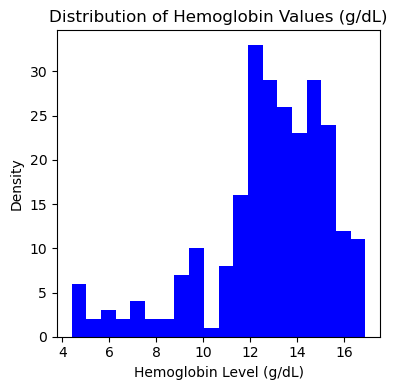

In [912]:
plot_hb_distribution(metadata)

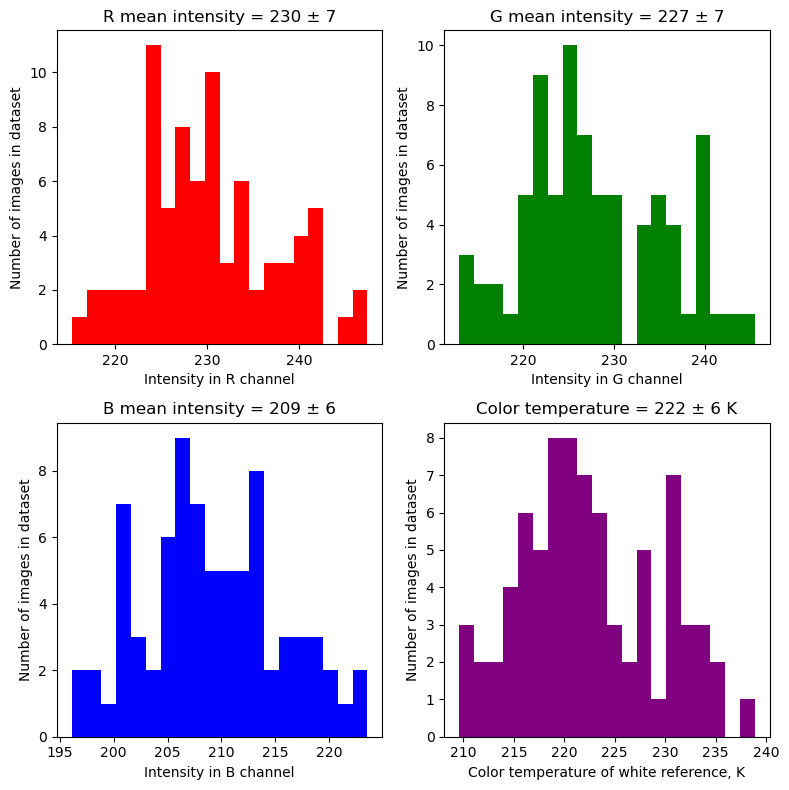

In [913]:
plot_white_reference_distributions(white_refs)

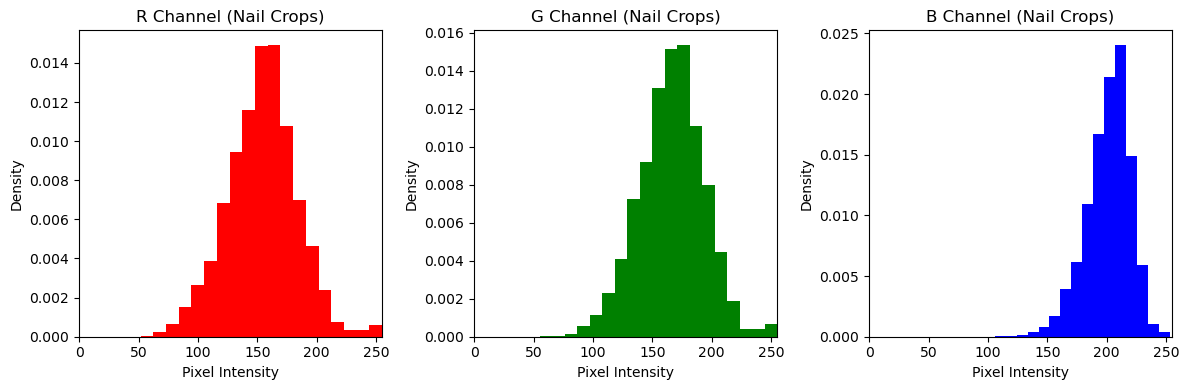

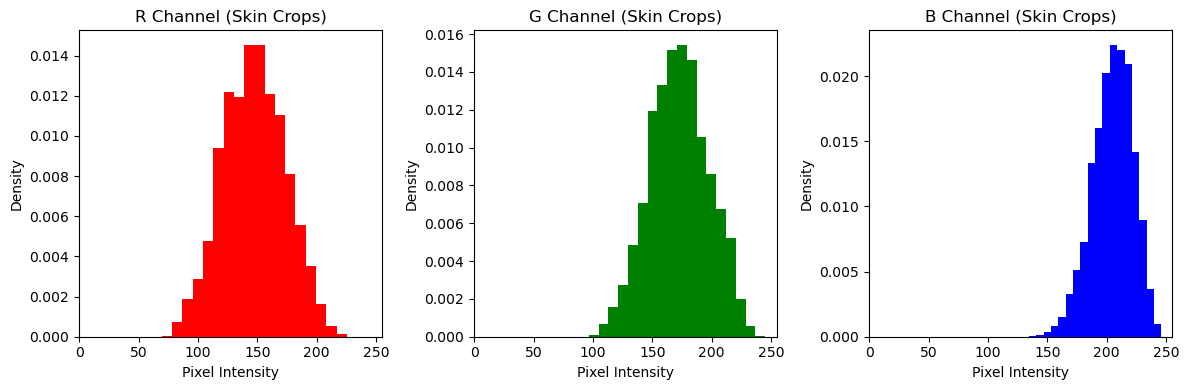

In [914]:
plot_rgb_channel_distributions(nail_crops, label='Nail Crops')
plot_rgb_channel_distributions(skin_crops, label='Skin Crops')

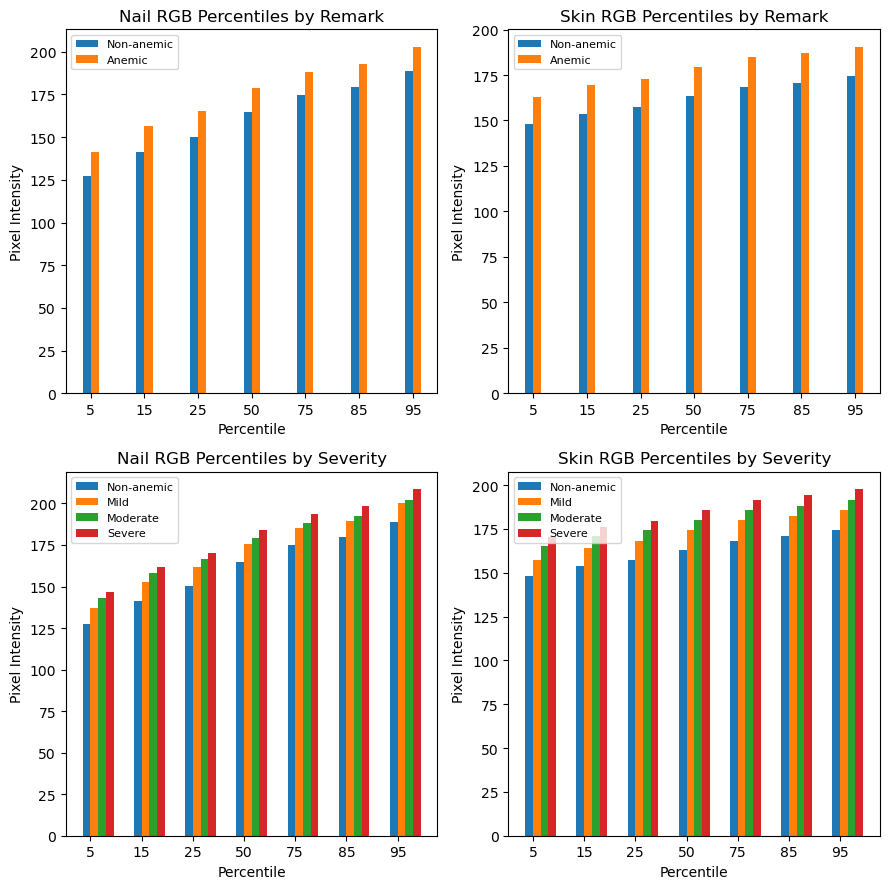

In [915]:
plot_percentile_histograms_by_class(df=metadata, data_dir=DATA_DIR)

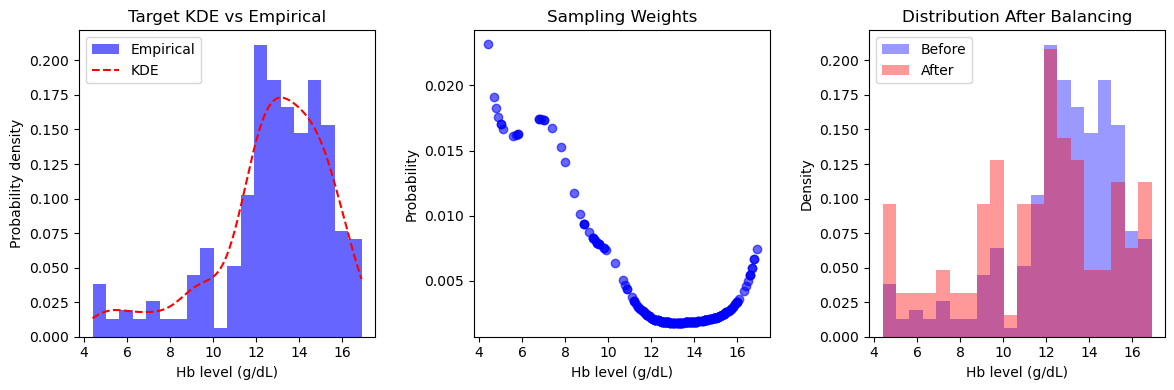

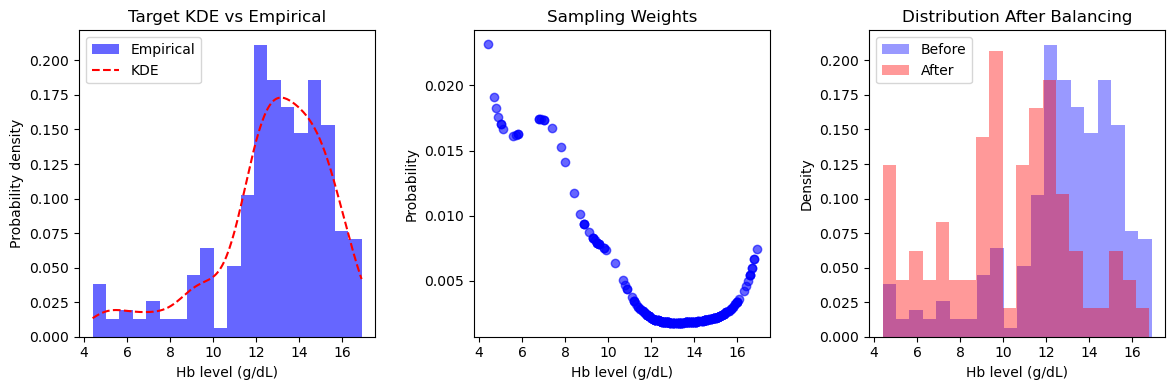

In [916]:
plot_target_balancing(metadata, metadata_balanced_remark)
plot_target_balancing(metadata, metadata_balanced_severity)

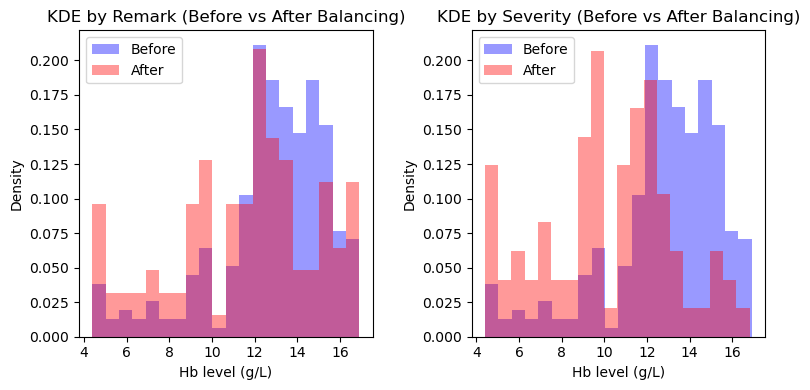

In [918]:
plot_class_kde_balanced(metadata, metadata_balanced_remark, metadata_balanced_severity)

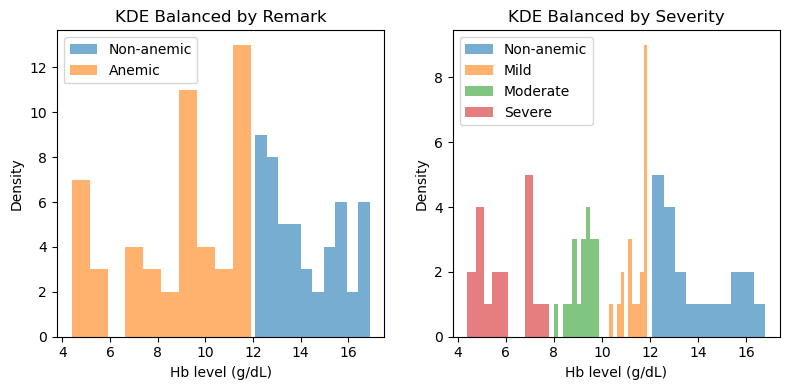

In [919]:
plot_class_distribution_by_class(metadata_balanced_remark, metadata_balanced_severity)

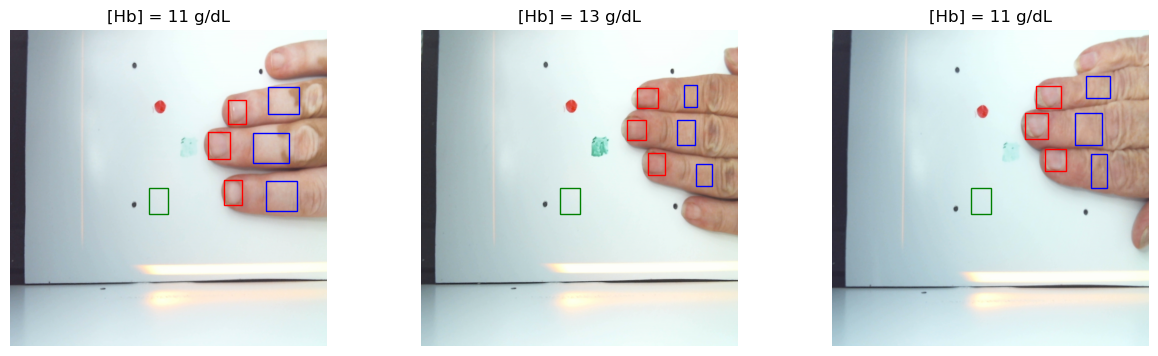

In [920]:
plot_sample_images(metadata, DATA_DIR, indices=[0, 1, 2])

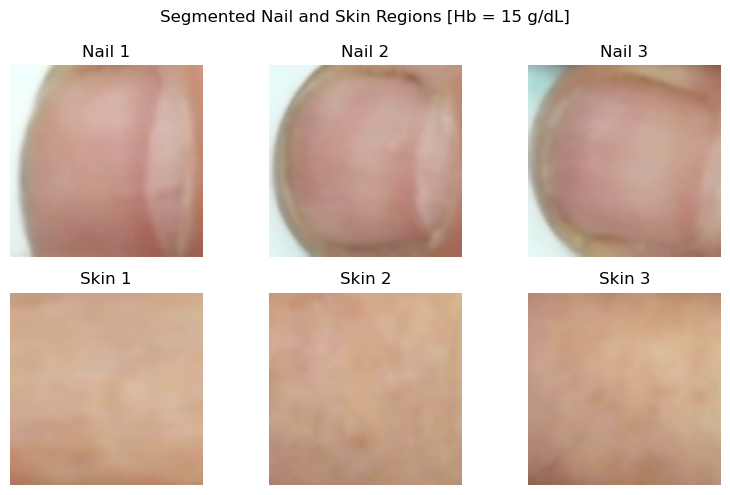

In [921]:
plot_segmented_regions(metadata, DATA_DIR, index=metadata.sample().index[0])

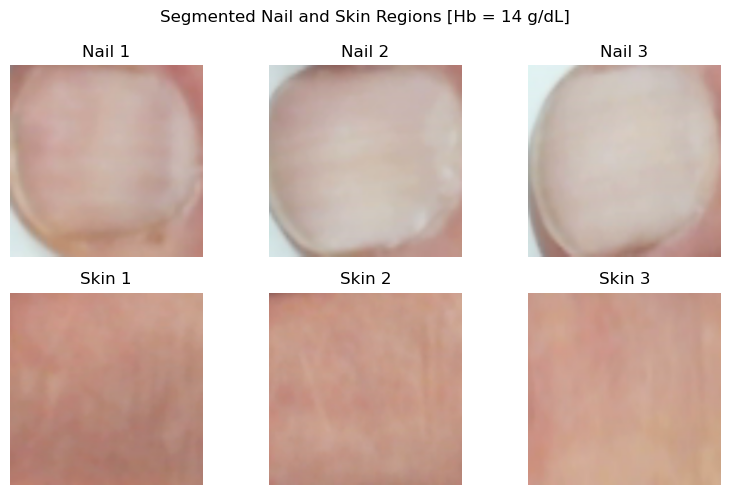

In [922]:
plot_segmented_regions(metadata, DATA_DIR, index=metadata.sample().index[0])

In [900]:
metadata.describe()

,PATIENT_ID,HB_LEVEL_GperL,HB_LEVEL_GperDeciL
count,250.00000,250.000000,250.000000
mean,170.32400,127.592000,12.759200
std,100.07296,26.709533,2.670953
min,1.00000,44.000000,4.400000
25%,79.50000,118.250000,11.825000
50%,175.50000,131.500000,13.150000
75%,252.75000,146.000000,14.600000
max,342.00000,169.000000,16.900000


In [904]:
metadata_balanced_remark.describe()

,PATIENT_ID,HB_LEVEL_GperL,HB_LEVEL_GperDeciL
count,100.000000,100.00000,100.000000
mean,177.020000,115.33000,11.533000
std,103.495472,33.25538,3.325538
min,5.000000,44.00000,4.400000
25%,86.750000,94.50000,9.450000
50%,176.500000,120.00000,12.000000
75%,276.750000,137.00000,13.700000
max,341.000000,169.00000,16.900000


In [905]:
metadata_balanced_severity.describe()

,PATIENT_ID,HB_LEVEL_GperL,HB_LEVEL_GperDeciL
count,78.000000,78.000000,78.000000
mean,175.743590,102.256410,10.225641
std,100.441937,30.538218,3.053822
min,2.000000,44.000000,4.400000
25%,88.750000,84.750000,8.475000
50%,181.500000,105.000000,10.500000
75%,261.750000,120.500000,12.050000
max,341.000000,168.000000,16.800000


Dataset Description:
1. Has 250 samples of patient recordings for anemia

    a. Consists of: a) Sample images of patients in .jpg format, b) Metadata with data recording information.
    
    b. Metadata contains: a) ID, b) Hemoglobin levels (g/L), c) Skin and Nailbed bounding boxes for three middle fingers

2. Not evenly distributed. Used Kernel-density Estimation to distribute sample subsets across hemoglobing levels, stratified by classes (both for remarks and severity)
3. Mostly "fair" skinned patient samples, thus diverse patient data acquisition is incrementally important.

Approach based on EDA perfomred:
1. Estimate hemoglobin levels using RGB-channel percentiles (5, 15, 25, 50, 75, 85, 95). A qualitative assessment showed that linearity is found within classes, especially when distinguishing remarks (anemic, non-anemic), however, feature vectors are easily obscured by the not noticeable difference between anemic severities. Limit the regression task to use a feature vector of RGB-channel percentiles to calculate the estimated hemoglobin level.
2. Since low-level features like RGB-channel percentiles are hard to distinguish between severity classes, these features can be extracted by non-linear relations through dense networks, especially capturing spatial relationships within an image vector to relate them to a specific class. Exploration of CNN feasibility for classification will consist of evaluating sensitivity/specificity for class predictions (binary:remark and multiclass:severity).